In [121]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully!")

Libraries imported successfully!


In [122]:
import urllib.request

url = "https://raw.githubusercontent.com/justmarkham/pycon-2016-tutorial/master/data/sms.tsv"

urllib.request.urlretrieve(url, "spam.csv")

print("Dataset downloaded successfully!")

Dataset downloaded successfully!


In [123]:
df = pd.read_csv("spam.csv", sep="\t", header=None, names=["label", "message"])

print("Dataset loaded successfully!")
df.head()

Dataset loaded successfully!


,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [124]:
print("Dataset Shape:", df.shape)

print("\nColumn Names:")
print(df.columns)

print("\nSpam and Ham Count:")
print(df["label"].value_counts())

print("\nMissing Values:")
print(df.isnull().sum())

Dataset Shape: (5572, 2)

Column Names:
Index(['label', 'message'], dtype='object')

Spam and Ham Count:
label
ham     4825
spam     747
Name: count, dtype: int64

Missing Values:
label      0
message    0
dtype: int64


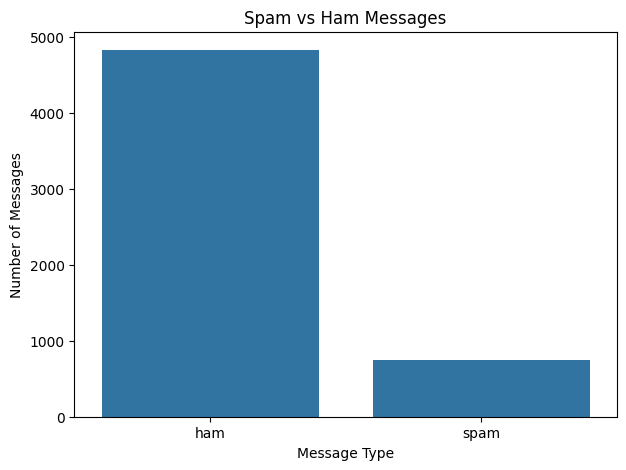

In [125]:
plt.figure(figsize=(7, 5))

sns.countplot(data=df, x="label")

plt.title("Spam vs Ham Messages")
plt.xlabel("Message Type")
plt.ylabel("Number of Messages")
plt.show()

In [126]:
X = df["message"]
y = df["label"]

print("Input and target variables created successfully!")

Input and target variables created successfully!


In [127]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training messages:", len(X_train))
print("Testing messages:", len(X_test))

Training messages: 4457
Testing messages: 1115


In [128]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer()

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

print("Text converted into numerical features successfully!")
print("Training data shape:", X_train_tfidf.shape)
print("Testing data shape:", X_test_tfidf.shape)

Text converted into numerical features successfully!
Training data shape: (4457, 7668)
Testing data shape: (1115, 7668)


In [129]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer()

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

print("Text converted into numerical features successfully!")
print("Training data shape:", X_train_tfidf.shape)
print("Testing data shape:", X_test_tfidf.shape)

Text converted into numerical features successfully!
Training data shape: (4457, 7668)
Testing data shape: (1115, 7668)


In [130]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)

model.fit(X_train_tfidf, y_train)

print("Model training completed successfully!")

Model training completed successfully!


In [131]:
y_pred = model.predict(X_test_tfidf)

print("Predictions generated successfully!")
print(y_pred[:20])

Predictions generated successfully!
['ham' 'ham' 'ham' 'spam' 'ham' 'ham' 'ham' 'ham' 'ham' 'ham' 'ham' 'ham'
 'ham' 'ham' 'ham' 'ham' 'ham' 'ham' 'ham' 'ham']


In [132]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Model Accuracy:", round(accuracy * 100, 2), "%")

Model Accuracy: 97.31 %


In [133]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        y_pred,
        target_names=["Ham", "Spam"]
    )
)

              precision    recall  f1-score   support

         Ham       0.97      1.00      0.98       966
        Spam       1.00      0.80      0.89       149

    accuracy                           0.97      1115
   macro avg       0.98      0.90      0.94      1115
weighted avg       0.97      0.97      0.97      1115



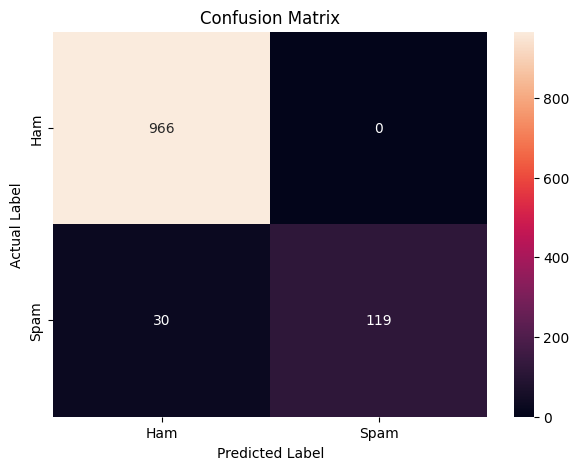

In [134]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=["Ham", "Spam"],
    yticklabels=["Ham", "Spam"]
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.show()

In [135]:
new_message = ["Congratulations! You have won a free prize. Click now!"]

new_message_tfidf = vectorizer.transform(new_message)

prediction = model.predict(new_message_tfidf)

print("Message:", new_message[0])
print("Prediction:", prediction[0])

Message: Congratulations! You have won a free prize. Click now!
Prediction: spam


In [136]:
new_message = ["Hey, are we meeting tomorrow for the project?"]

new_message_tfidf = vectorizer.transform(new_message)

prediction = model.predict(new_message_tfidf)

print("Message:", new_message[0])
print("Prediction:", prediction[0])

Message: Hey, are we meeting tomorrow for the project?
Prediction: ham


Conclusion

The Spam Mail Detector successfully classifies messages as Spam or Ham
using Machine Learning. TF-IDF was used to convert text messages into
numerical features, and Logistic Regression was used for classification.
The model was evaluated using accuracy, classification report, and
confusion matrix. The trained model can also predict whether a new
message is Spam or Ham.